<div style="text-align:center; font-size:26px; font-weight:bold; margin-bottom:25px;">
基于Python与OpenCV的GIS栅格数据处理及空间分析实验
</div>

<div style="font-size:17px; line-height:2; text-align:justify; text-indent:2em;">

本组实验以Python为主要开发工具，围绕GIS栅格数据处理与OpenCV图像处理方法展开。实验数据主要采用GeoTIFF格式的遥感影像和DEM栅格数据，通过Rasterio读取影像的空间参考、像元大小和波段信息，再结合openCV进行灰度化、滤波、边缘检测、图像增强和分类处理。在完成图像处理后，进一步利用NumPy和Scikit-learn进行像元统计、K-Means聚类分类、面积计算和比例分析，最后通过Matplotlib对实验结果进行制图表达，形成原始影像图、灰度图、边缘检测图、地形突变区图、分类结果图和面积统计图。
<br><br>

本组实验按照由浅入深的思路设计。实验一和实验二为基础实验，分别完成遥感影像地物边缘提取和 DEM 地形突变区识别；实验三为综合实验，进一步完成遥感影像增强、K-Means 聚类分类、空间面积统计和结果制图。整套实验能够较好体现 OpenCV 图像处理方法在 GIS 栅格空间分析中的应用价值。
</div>

<div style="font-size:20px; line-height:2; text-align:left; font-weight:bold; margin-left:0; padding-left:0;">
  实验一：遥感影像地物边缘提取与空间统计分析
</div>

<div style="font-size:16px; line-height:2; text-align:left; font-weight:bold; margin-left:0; padding-left:0;">
  1. 实验目的
</div>

<div style="font-size:14px; line-height:2; text-align:justify; text-indent:2em;">

掌握使用 Python 读取 GeoTIFF 遥感影像的方法，并利用 OpenCV 对影像进行灰度化和 Canny 边缘检测。通过统计边缘像元数量，计算边缘像元对应面积，理解图像边缘检测在 GIS 栅格空间分析中的基本应用。
</div>

<div style="font-size:16px; line-height:2; text-align:left; font-weight:bold; margin-left:0; padding-left:0;">
  2. 实验数据
</div>

<div style="font-size:14px; line-height:2; text-align:justify; text-indent:2em;">

GitHub 数据；https://github.com/mommermi/geotiff_sample.git
</div>

<div style="font-size:16px; line-height:2; text-align:left; font-weight:bold; margin-left:0; padding-left:0;">
  3. 实验代码
</div>

In [1]:
import os
import cv2
import requests
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
plt.rcParams['font.sans-serif']=['SimHei']

In [3]:
plt.rcParams['axes.unicode_minus']=False

In [4]:
data_dir="data"

In [5]:
output_dir="output/exp1_edge"

In [6]:
os.makedirs(data_dir,exist_ok=True)

In [7]:
os.makedirs(output_dir,exist_ok=True)

In [8]:
url="https://raw.githubusercontent.com/mommermi/geotiff_sample/master/sample.tif"

In [9]:
tif_path=os.path.join(data_dir,"sample.tif")

In [10]:
response=requests.get(url,timeout=30)

In [11]:
if response.status_code==200:
    with open(tif_path,"wb")as f:
        f.write(response.content)
        print("数据获取成功",tif_path)
else:
    print("数据获取失败",response.status_code)

数据获取成功 data\sample.tif


In [12]:
with rasterio.open(tif_path) as src:
    image_data=src.read()
    transform=src.transform
    crs=src.crs
    width=src.width
    height=src.height
    band_count=src.count

In [13]:
print("形状：",image_data)
print("仿射变换参数：",transform)
print("坐标系：",crs)
print("影像宽度：",width)
print("影像高度：",height)
print("波段数量：",band_count)

形状： [[[   0  799  788 ... 1061 1433 2430]
  [   0  774  792 ... 1027 1125 1733]
  [   0  797  801 ... 1046 1040 1100]
  ...
  [   0  826  837 ... 1562 1489 1740]
  [   0  804  825 ... 1553 1582 1619]
  [   0    0    0 ...    0    0    0]]

 [[   0  555  546 ... 1106 1353 2280]
  [   0  534  533 ... 1074 1154 1650]
  [   0  548  553 ... 1077 1070 1151]
  ...
  [   0  644  627 ... 1440 1351 1859]
  [   0  628  634 ... 1498 1605 1562]
  [   0    0    0 ...    0    0    0]]

 [[   0  330  322 ...  823 1263 2408]
  [   0  304  313 ...  771  859 1492]
  [   0  320  323 ...  790  817  915]
  ...
  [   0  397  403 ... 1562 1415 1825]
  [   0  392  408 ... 1573 1680 1780]
  [   0    0    0 ...    0    0    0]]]
仿射变换参数： | 10.00, 0.00, 590520.00|
| 0.00,-10.00, 5790630.00|
| 0.00, 0.00, 1.00|
坐标系： PROJCS["WGS 84 / UTM zone 31N",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"

In [14]:
pixel_width=abs(transform.a)

In [15]:
pixel_height=abs(transform.e)

In [16]:
pixel_area=pixel_width*pixel_height

In [17]:
total_pixels=width*height

In [18]:
total_area=pixel_area*total_pixels

In [19]:
print("像元宽度",pixel_width)
print("像元高度",pixel_height)
print("像元面积",pixel_area)
print("像元数量",total_pixels)
print("像元总面积",total_area)

像元宽度 10.0
像元高度 10.0
像元面积 100.0
像元数量 1002001
像元总面积 100200100.0


In [20]:
def normalize_to_uint8(array):
    array=array.astype(np.float32)
    min_value=np.nanmin(array)
    max_value=np.nanmax(array)
    if max_value==min_value:
        return np.zeros(array.shape,dtype=np.uint8)
    normalized=(array-min_value)/(max_value-min_value)*255
    normalized=np.clip(normalized,0,255)
    return normalized.astype(np.uint8)

In [21]:
if band_count>=3:
    band1=normalize_to_uint8(image_data[0])
    band2=normalize_to_uint8(image_data[1])
    band3=normalize_to_uint8(image_data[2])
    rgb_image=np.dstack([band1,band2,band3])
else:
    band1=normalize_to_uint8(image_data[0])
    rgb_image=np.dstack([band1,band1,band1])

In [22]:
print("RGB 影像形状：", rgb_image.shape)
print("RGB 影像数据类型：", rgb_image.dtype)

RGB 影像形状： (1001, 1001, 3)
RGB 影像数据类型： uint8


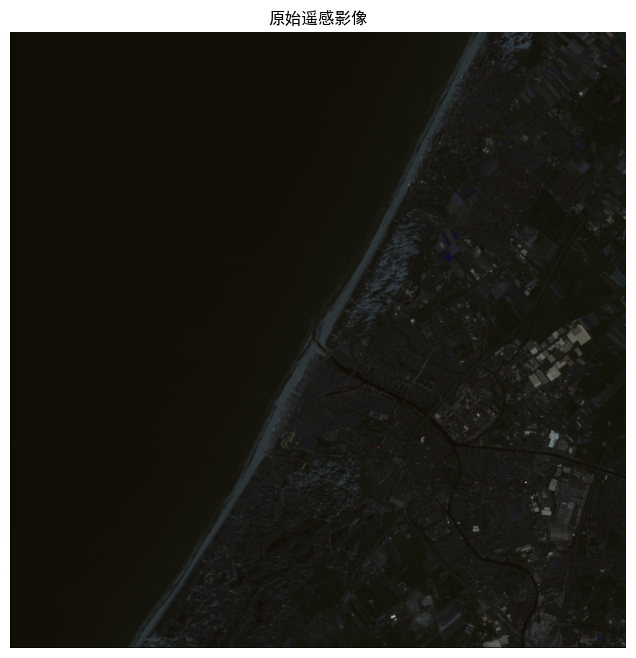

已保存: output/exp1_edge\实验一原始影像


In [23]:
plt.figure(figsize=(8,8))
plt.imshow(rgb_image)
plt.title("原始遥感影像")
plt.axis("off")
save_path=os.path.join(output_dir,"实验一原始影像")
plt.savefig(save_path,dpi=600,bbox_inches="tight")
plt.show()
print("已保存:",save_path)

In [24]:
gray_image=cv2.cvtColor(rgb_image,cv2.COLOR_RGB2GRAY)
print("灰度图形状；",gray_image.shape)
print("灰度图数据类型：",gray_image.dtype)

灰度图形状； (1001, 1001)
灰度图数据类型： uint8


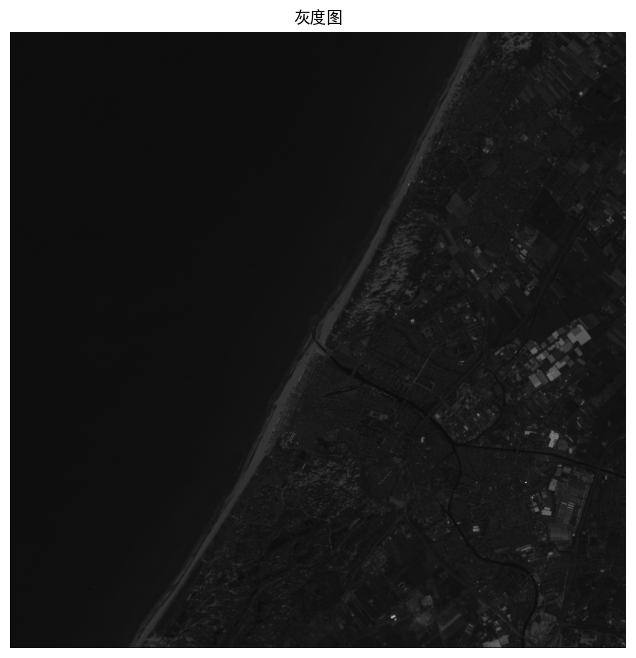

已保存： output/exp1_edge\灰度图.png


In [25]:
plt.figure(figsize=(8,8))
plt.imshow(gray_image,cmap="gray")
plt.title("灰度图")
plt.axis("off")
save_path=os.path.join(output_dir,"灰度图.png")
plt.savefig(save_path,dpi=600,bbox_inches="tight")
plt.show()
print("已保存：",save_path)

In [26]:
lower_threshold=50
upper_threshold=150

In [27]:
edge_image=cv2.Canny(gray_image,lower_threshold,upper_threshold)
print("边缘检测图形状:",edge_image.shape)
print("边缘检测图中的唯一值:",np.unique(edge_image))

边缘检测图形状: (1001, 1001)
边缘检测图中的唯一值: [  0 255]


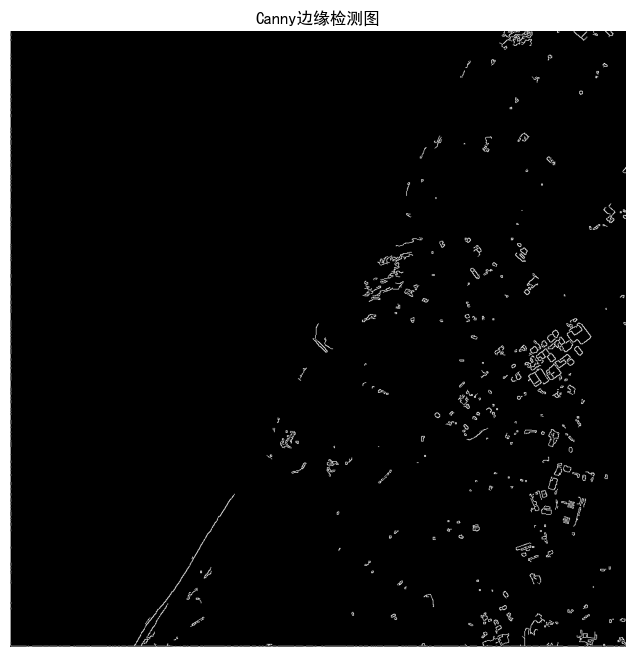

已保存 output/exp1_edge\Canny边缘检测图.png


In [28]:
plt.figure(figsize=(8,8))
plt.imshow(edge_image,cmap="gray")
plt.title("Canny边缘检测图")
plt.axis("off")
save_path=os.path.join(output_dir,"Canny边缘检测图.png")
plt.savefig(save_path,dpi=600,bbox_inches="tight")
plt.show()
print("已保存",save_path)

In [29]:
edge_pixels=np.sum(edge_image>0)

In [30]:
non_edge_pixels=total_pixels-edge_pixels

In [31]:
edge_area=edge_pixels*pixel_area

In [32]:
non_edge_area=non_edge_pixels*pixel_area

In [33]:
edge_ratio=edge_pixels/total_pixels

In [34]:
print("边缘像元数量：", edge_pixels)
print("非边缘像元数量：", non_edge_pixels)
print("边缘像元对应面积：", edge_area)
print("非边缘像元对应面积：", non_edge_area)
print("边缘比例：", edge_ratio)

边缘像元数量： 12067
非边缘像元数量： 989934
边缘像元对应面积： 1206700.0
非边缘像元对应面积： 98993400.0
边缘比例： 0.012042902152792263


In [35]:
statistics_df=pd.DataFrame({
    "统计指标": [
        "影像宽度",
        "影像高度",
        "总像元数量",
        "像元宽度",
        "像元高度",
        "单个像元面积",
        "边缘像元数量",
        "非边缘像元数量",
        "边缘像元对应面积",
        "非边缘像元对应面积",
        "边缘比例"
    ],
    "数值": [
        width,
        height,
        total_pixels,
        pixel_width,
        pixel_height,
        pixel_area,
        edge_pixels,
        non_edge_pixels,
        edge_area,
        non_edge_area,
        edge_ratio
    ]
})

In [134]:
statistics_df

,统计指标,数值
0,影像宽度,1.001000e+03
1,影像高度,1.001000e+03
2,总像元数量,1.002001e+06
3,像元宽度,1.000000e+01
4,像元高度,1.000000e+01
5,单个像元面积,1.000000e+02
6,边缘像元数量,1.206700e+04
7,非边缘像元数量,9.899340e+05
8,边缘像元对应面积,1.206700e+06
9,非边缘像元对应面积,9.899340e+07


In [36]:
excel_path=os.path.join(output_dir,"边缘统计表.xlsx")

In [37]:
statistics_df.to_excel(excel_path,index=False)
print("已保存",excel_path)

已保存 output/exp1_edge\边缘统计表.xlsx


In [38]:
area_df=pd.DataFrame({
    "类型": ["边缘区域", "非边缘区域"],
    "面积": [edge_area, non_edge_area]
})

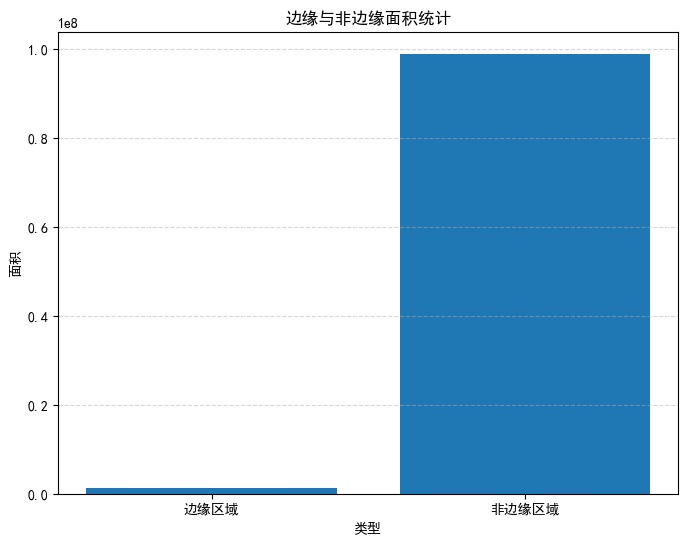

已保存 output/exp1_edge\边缘面积统计图.png


In [39]:
plt.figure(figsize=(8,6))
plt.bar(area_df["类型"],area_df["面积"])
plt.title("边缘与非边缘面积统计")
plt.xlabel("类型")
plt.ylabel("面积")
plt.grid(axis="y",linestyle="--",alpha=0.5)
save_path=os.path.join(output_dir,"边缘面积统计图.png")
plt.savefig(save_path,dpi=600,bbox_inches="tight")
plt.show()
print("已保存",save_path)

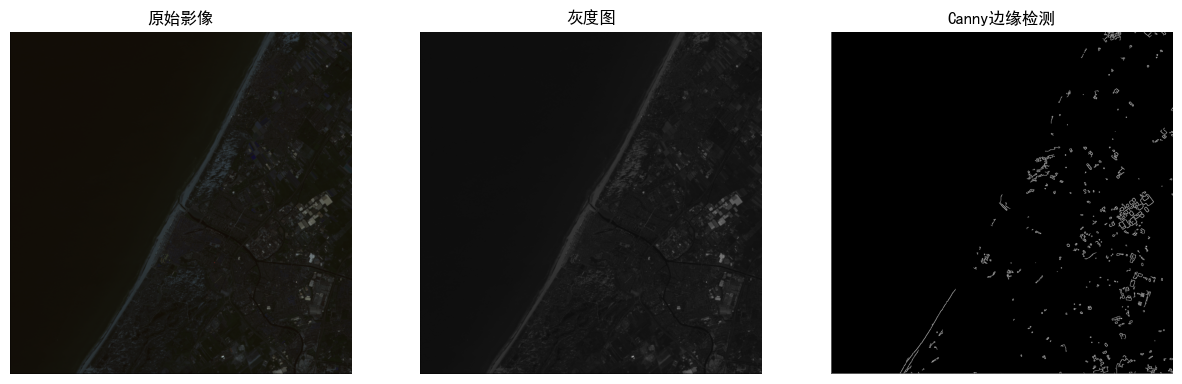

已保存： output/exp1_edge\综合对比图.png


In [40]:
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(rgb_image)
plt.title("原始影像")
plt.axis("off")
plt.subplot(1,3,2)
plt.imshow(gray_image, cmap="gray")
plt.title("灰度图")
plt.axis("off")
plt.subplot(1,3,3)
plt.imshow(edge_image, cmap="gray")
plt.title("Canny边缘检测")
plt.axis("off")
save_path = os.path.join(output_dir, "综合对比图.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()
print("已保存：", save_path)

<div style="font-size:20px; line-height:2; text-align:left; font-weight:bold; margin-left:0; padding-left:0;">
  实验二：DEM 地形变化识别与空间统计分析
</div>

<div style="font-size:16px; line-height:2; text-align:left; font-weight:bold; margin-left:0; padding-left:0;">
  1. 实验目的
</div>

<div style="font-size:14px; line-height:2; text-align:justify; text-indent:2em;">

本实验以单波段 GeoTIFF 栅格数据为研究对象，利用 Python 读取栅格数据的空间参考、像元大小和栅格数值信息，并结合 OpenCV 图像处理方法识别地形或连续型栅格中数值变化明显的位置。实验首先使用 Rasterio 读取 DEM 或单波段连续型 GeoTIFF 数据，然后将栅格数值归一化为 0—255 灰度图，再利用 OpenCV 中的 Sobel 算子提取地形变化强度。最后通过设置阈值提取变化明显区域，并结合像元面积计算变化区像元数量、变化区面积和变化区比例。
通过本实验，可以掌握 Python 读取单波段 GeoTIFF 栅格数据的方法，理解 Sobel 算子在地形突变区识别中的基本应用，并进一步掌握将图像处理结果转化为空间统计结果的基本流程。
</div>

<div style="font-size:16px; line-height:2; text-align:left; font-weight:bold; margin-left:0; padding-left:0;">
  2. 实验数据
</div>

<div style="font-size:14px; line-height:2; text-align:justify; text-indent:2em;">

使用 GitHub 中 GeoTIFF/test-data 仓库提供的测试 GeoTIFF 数据。该仓库是 GeoTIFF 测试数据仓库，仓库文件列表中包含 LisbonElevation.tif，本实验选取该文件作为 DEM 或单波段连续型栅格数据进行方法演示。
实验数据地址：https://github.com/GeoTIFF/test-data
本实验使用的具体文件为：LisbonElevation.tif
</div>

<div style="font-size:16px; line-height:2; text-align:left; font-weight:bold; margin-left:0; padding-left:0;">
  3. 实验代码
</div>

In [41]:
import os
import requests
import cv2
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import pandas as pd

In [42]:
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
data_dir = "data"
output_dir = "output/exp2_dem"
os.makedirs(data_dir, exist_ok=True)
os.makedirs(output_dir, exist_ok=True)
url = "https://raw.githubusercontent.com/GeoTIFF/test-data/main/files/LisbonElevation.tif"
dem_path = os.path.join(data_dir, "LisbonElevation.tif")
response = requests.get(url, timeout=60)
if response.status_code == 200:
    with open(dem_path, "wb") as f:
        f.write(response.content)
    print("数据读取成功，已保存到：", dem_path)
else:
    print("数据读取失败，状态码：", response.status_code)

数据读取成功，已保存到： data\LisbonElevation.tif


In [43]:
with rasterio.open(dem_path) as src:
    dem_data = src.read(1).astype(np.float32)   
    transform = src.transform                   
    crs = src.crs                            
    width = src.width                           
    height = src.height                      
    nodata = src.nodata                      
print("影像宽度：", width)
print("影像高度：", height)
print("坐标系：", crs)
print("NoData 值：", nodata)
print("DEM 数组形状：", dem_data.shape)
print("仿射变换参数：")
print(transform)

影像宽度： 547
影像高度： 421
坐标系： GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST]]
NoData 值： None
DEM 数组形状： (421, 547)
仿射变换参数：
| 0.00, 0.00,-9.24|
| 0.00,-0.00, 38.80|
| 0.00, 0.00, 1.00|


In [44]:
if nodata is not None:
    dem_data[dem_data == nodata] = np.nan
valid_mask = np.isfinite(dem_data)
min_value = np.nanmin(dem_data)
max_value = np.nanmax(dem_data)
mean_value = np.nanmean(dem_data)
print("最小值：", min_value)
print("最大值：", max_value)
print("平均值：", mean_value)

最小值： -6.8294387
最大值： 217.94075
平均值： 38.763477


In [45]:
pixel_width = abs(transform.a)
pixel_height = abs(transform.e)
pixel_area = pixel_width * pixel_height
total_valid_pixels = np.sum(valid_mask)
total_area = total_valid_pixels * pixel_area
print("像元宽度：", pixel_width)
print("像元高度：", pixel_height)
print("单个像元面积：", pixel_area)
print("有效像元数量：", total_valid_pixels)
print("总有效面积：", total_area)

像元宽度： 0.0002777777778394889
像元高度： 0.00027777777839489205
单个像元面积： 7.71604940157231e-08
有效像元数量： 230287
总有效面积： 0.017769058685398825


In [46]:
def normalize_to_uint8(array):
    """
    将单波段栅格数组归一化到 0—255，并转换为 uint8 类型。
    """
    array = array.astype(np.float32)
    valid = np.isfinite(array)
    output = np.zeros(array.shape, dtype=np.uint8)
    if np.sum(valid) == 0:
        return output
    min_val = np.nanmin(array)
    max_val = np.nanmax(array)
    if max_val == min_val:
        return output
    normalized = (array - min_val) / (max_val - min_val) * 255
    normalized = np.clip(normalized, 0, 255)
    output[valid] = normalized[valid].astype(np.uint8)
    return output

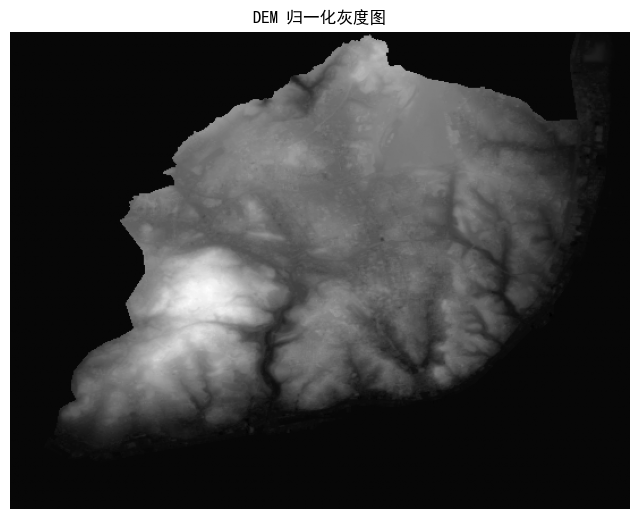

已保存： output/exp2_dem\DEM灰度图.png


In [47]:
dem_gray = normalize_to_uint8(dem_data)
plt.figure(figsize=(8, 8))
plt.imshow(dem_gray, cmap="gray")
plt.title("DEM 归一化灰度图")
plt.axis("off")
save_path = os.path.join(output_dir, "DEM灰度图.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()
print("已保存：", save_path)

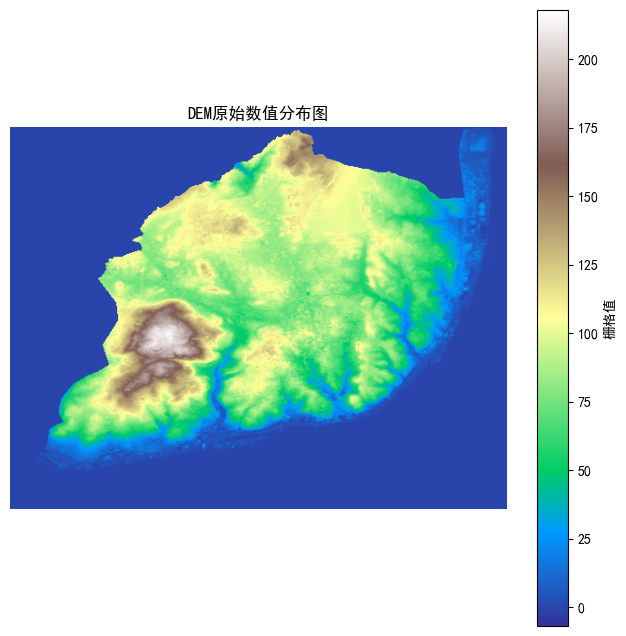

已保存： output/exp2_dem\DEM原始数值图.png


In [48]:
plt.figure(figsize=(8, 8))
plt.imshow(dem_data, cmap="terrain")
plt.title("DEM原始数值分布图")
plt.colorbar(label="栅格值")
plt.axis("off")
save_path = os.path.join(output_dir, "DEM原始数值图.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()
print("已保存：", save_path)

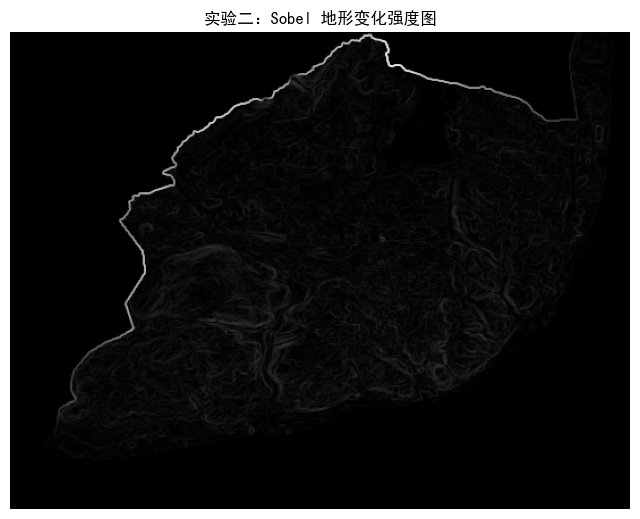

已保存： output/exp2_dem\实验二_Sobel变化强度图.png


In [49]:
sobel_x = cv2.Sobel(dem_gray, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(dem_gray, cv2.CV_64F, 0, 1, ksize=3)
sobel_magnitude = np.sqrt(sobel_x ** 2 + sobel_y ** 2)
sobel_image = normalize_to_uint8(sobel_magnitude)
plt.figure(figsize=(8, 8))
plt.imshow(sobel_image, cmap="gray")
plt.title("实验二：Sobel 地形变化强度图")
plt.axis("off")
save_path = os.path.join(output_dir, "实验二_Sobel变化强度图.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()
print("已保存：", save_path)

变化区提取阈值： 15.0


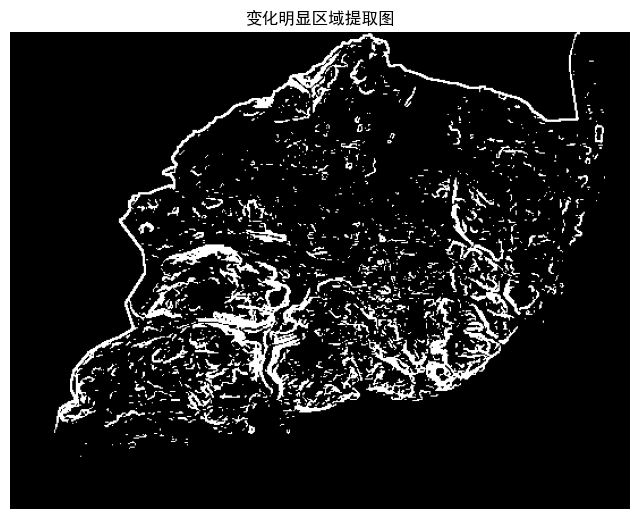

已保存： output/exp2_dem\变化明显区域图.png


In [50]:
positive_values = sobel_image[sobel_image > 0]
if len(positive_values) > 0:
    threshold_value = np.percentile(positive_values, 85)
else:
    threshold_value = 30
print("变化区提取阈值：", threshold_value)
change_area = np.zeros(sobel_image.shape, dtype=np.uint8)
change_area[sobel_image >= threshold_value] = 255
plt.figure(figsize=(8, 8))
plt.imshow(change_area, cmap="gray")
plt.title("变化明显区域提取图")
plt.axis("off")
save_path = os.path.join(output_dir, "变化明显区域图.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()
print("已保存：", save_path)

In [51]:
change_pixels = np.sum(change_area > 0)
non_change_pixels = total_valid_pixels - change_pixels
change_area_size = change_pixels * pixel_area
non_change_area_size = non_change_pixels * pixel_area
change_ratio = change_pixels / total_valid_pixels
print("变化区像元数量：", change_pixels)
print("非变化区像元数量：", non_change_pixels)
print("变化区面积：", change_area_size)
print("非变化区面积：", non_change_area_size)
print("变化区比例：", change_ratio)

变化区像元数量： 19838
非变化区像元数量： 210449
变化区面积： 0.0015307098802839149
非变化区面积： 0.016238348805114912
变化区比例： 0.08614468033367059


In [52]:
statistics_df = pd.DataFrame({
    "统计指标": [
        "影像宽度",
        "影像高度",
        "有效像元数量",
        "像元宽度",
        "像元高度",
        "单个像元面积",
        "最小值",
        "最大值",
        "平均值",
        "变化区像元数量",
        "非变化区像元数量",
        "变化区面积",
        "非变化区面积",
        "变化区比例"
    ],
    "数值": [
        width,
        height,
        total_valid_pixels,
        pixel_width,
        pixel_height,
        pixel_area,
        min_value,
        max_value,
        mean_value,
        change_pixels,
        non_change_pixels,
        change_area_size,
        non_change_area_size,
        change_ratio
    ]
})
statistics_df

,统计指标,数值
0,影像宽度,5.470000e+02
1,影像高度,4.210000e+02
2,有效像元数量,2.302870e+05
3,像元宽度,2.777778e-04
4,像元高度,2.777778e-04
5,单个像元面积,7.716049e-08
6,最小值,-6.829439e+00
7,最大值,2.179408e+02
8,平均值,3.876348e+01
9,变化区像元数量,1.983800e+04


In [53]:
excel_path = os.path.join(output_dir, "变化区统计表.xlsx")
statistics_df.to_excel(excel_path, index=False)
print("统计表已保存：", excel_path)

统计表已保存： output/exp2_dem\变化区统计表.xlsx


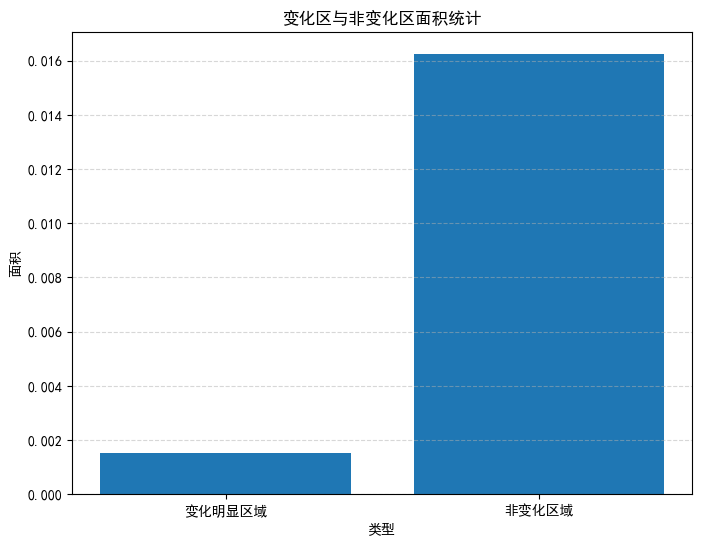

已保存： output/exp2_dem\变化区面积统计图.png


In [54]:
area_df = pd.DataFrame({
    "类型": ["变化明显区域", "非变化区域"],
    "面积": [change_area_size, non_change_area_size]
})
plt.figure(figsize=(8, 6))
plt.bar(area_df["类型"], area_df["面积"])
plt.title("变化区与非变化区面积统计")
plt.xlabel("类型")
plt.ylabel("面积")
plt.grid(axis="y", linestyle="--", alpha=0.5)
save_path = os.path.join(output_dir, "变化区面积统计图.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()
print("已保存：", save_path)

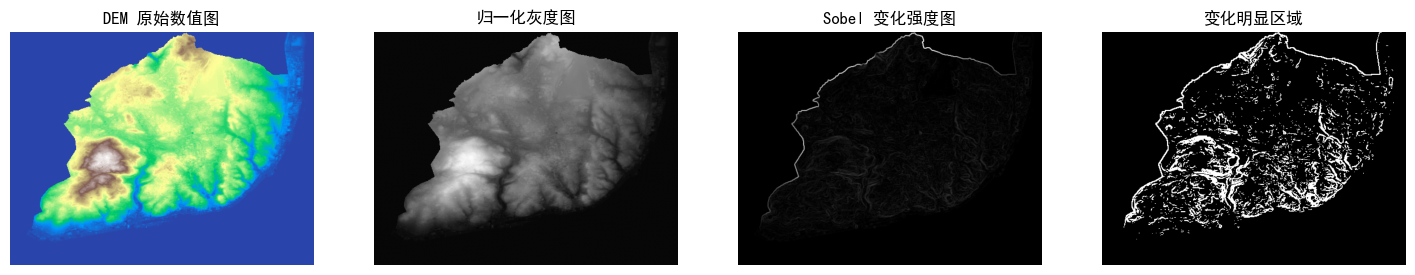

已保存： output/exp2_dem\综合对比图.png


In [55]:
plt.figure(figsize=(18, 5))
plt.subplot(1, 4, 1)
plt.imshow(dem_data, cmap="terrain")
plt.title("DEM 原始数值图")
plt.axis("off")
plt.subplot(1, 4, 2)
plt.imshow(dem_gray, cmap="gray")
plt.title("归一化灰度图")
plt.axis("off")
plt.subplot(1, 4, 3)
plt.imshow(sobel_image, cmap="gray")
plt.title("Sobel 变化强度图")
plt.axis("off")
plt.subplot(1, 4, 4)
plt.imshow(change_area, cmap="gray")
plt.title("变化明显区域")
plt.axis("off")
save_path = os.path.join(output_dir, "综合对比图.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()
print("已保存：", save_path)

<div style="font-size:20px; line-height:2; text-align:left; font-weight:bold; margin-left:0; padding-left:0;">
  实验三：遥感影像简单聚类分类与面积统计
</div>

<div style="font-size:16px; line-height:2; text-align:left; font-weight:bold; margin-left:0; padding-left:0;">
  1. 实验目的
</div>

<div style="font-size:14px; line-height:2; text-align:justify; text-indent:2em;">

本实验以 GeoTIFF 格式遥感影像为实验数据，利用 Python 读取遥感影像的波段信息、空间参考和像元大小，并结合 K-Means 无监督聚类方法对影像进行简单分类。实验首先使用 Rasterio 读取遥感影像的前三个波段，并将其归一化为 0—255 范围的 RGB 影像；随后将每个像元的 RGB 值作为分类特征，利用 Scikit-learn 中的 KMeans 方法将影像划分为若干类别；最后统计每一类的像元数量、面积和面积比例，并绘制分类结果图和面积统计图。
通过本实验，可以掌握遥感影像无监督分类的基本流程，理解 K-Means 聚类在遥感影像分类中的应用方法，并进一步掌握如何将分类结果与 GIS 像元面积相结合，完成地物类型面积统计和空间分布分析。
</div>

<div style="font-size:16px; line-height:2; text-align:left; font-weight:bold; margin-left:0; padding-left:0;">
  2. 实验数据
</div>

<div style="font-size:14px; line-height:2; text-align:justify; text-indent:2em;">

实验三继续使用实验一中的 GitHub GeoTIFF 遥感影像样本：https://github.com/mommermi/geotiff_sample
具体使用文件为：sample.tif
</div>

<div style="font-size:16px; line-height:2; text-align:left; font-weight:bold; margin-left:0; padding-left:0;">
  3. 实验代码
</div>

In [56]:
import os
import requests
import cv2
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans

In [57]:
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
data_dir = "data"
output_dir = "output/exp3_kmeans"
os.makedirs(data_dir, exist_ok=True)
os.makedirs(output_dir, exist_ok=True)
url = "https://raw.githubusercontent.com/mommermi/geotiff_sample/master/sample.tif"
tif_path = os.path.join(data_dir, "sample.tif")
response = requests.get(url, timeout=60)
if response.status_code == 200:
    with open(tif_path, "wb") as f:
        f.write(response.content)
    print("数据读取成功，已保存到：", tif_path)
else:
    print("数据读取失败，状态码：", response.status_code)

数据读取成功，已保存到： data\sample.tif


In [58]:
with rasterio.open(tif_path) as src:
    image_data = src.read()        
    transform = src.transform       
    crs = src.crs                    
    width = src.width               
    height = src.height             
    band_count = src.count         
print("影像宽度：", width)
print("影像高度：", height)
print("波段数量：", band_count)
print("坐标系：", crs)
print("影像数组形状：", image_data.shape)
print("仿射变换参数：")
print(transform)

影像宽度： 1001
影像高度： 1001
波段数量： 3
坐标系： PROJCS["WGS 84 / UTM zone 31N",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",3],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
影像数组形状： (3, 1001, 1001)
仿射变换参数：
| 10.00, 0.00, 590520.00|
| 0.00,-10.00, 5790630.00|
| 0.00, 0.00, 1.00|


In [59]:
pixel_width = abs(transform.a)
pixel_height = abs(transform.e)
pixel_area = pixel_width * pixel_height
total_pixels = width * height
total_area = total_pixels * pixel_area
print("像元宽度：", pixel_width)
print("像元高度：", pixel_height)
print("单个像元面积：", pixel_area)
print("总像元数量：", total_pixels)
print("总影像面积：", total_area)

像元宽度： 10.0
像元高度： 10.0
单个像元面积： 100.0
总像元数量： 1002001
总影像面积： 100200100.0


In [60]:
def normalize_to_uint8(array):
    """
    将单个波段归一化到 0—255，并转换为 uint8 类型。
    """
    array = array.astype(np.float32)
    min_value = np.nanmin(array)
    max_value = np.nanmax(array)
    if max_value == min_value:
        return np.zeros(array.shape, dtype=np.uint8)
    normalized = (array - min_value) / (max_value - min_value) * 255
    normalized = np.clip(normalized, 0, 255)
    return normalized.astype(np.uint8)

In [61]:
if band_count >= 3:
    band1 = normalize_to_uint8(image_data[0])
    band2 = normalize_to_uint8(image_data[1])
    band3 = normalize_to_uint8(image_data[2])
    rgb_image = np.dstack([band1, band2, band3])
else:
    band1 = normalize_to_uint8(image_data[0])
    rgb_image = np.dstack([band1, band1, band1])
print("RGB 影像形状：", rgb_image.shape)
print("RGB 影像数据类型：", rgb_image.dtype)

RGB 影像形状： (1001, 1001, 3)
RGB 影像数据类型： uint8


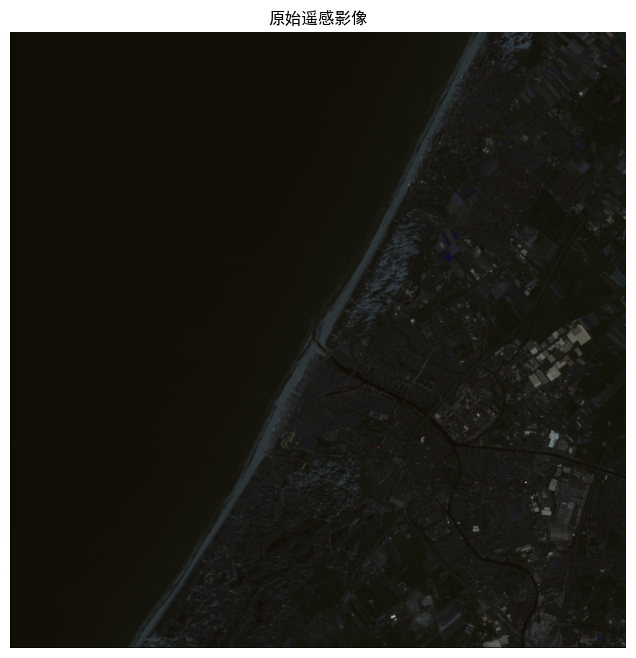

已保存： output/exp3_kmeans\原始遥感影像图.png


In [62]:
plt.figure(figsize=(8, 8))
plt.imshow(rgb_image)
plt.title("原始遥感影像")
plt.axis("off")
save_path = os.path.join(output_dir, "原始遥感影像图.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()
print("已保存：", save_path)

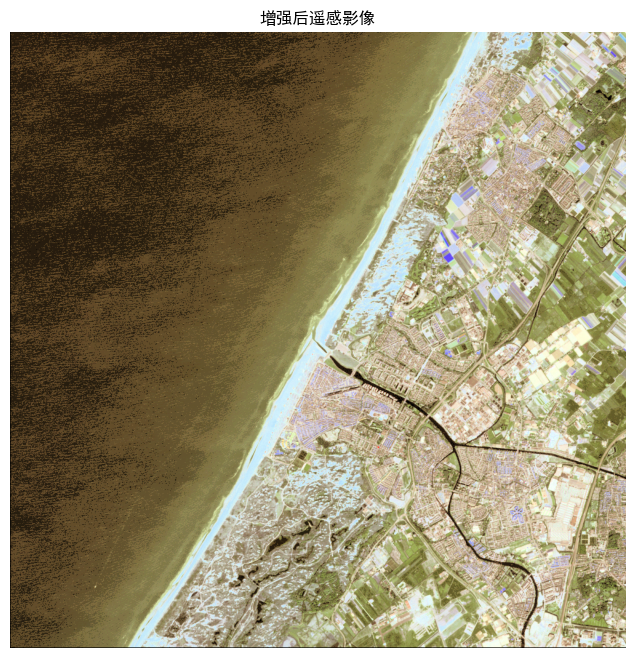

已保存： output/exp3_kmeans\增强后影像图.png


In [63]:
hsv_image = cv2.cvtColor(rgb_image, cv2.COLOR_RGB2HSV)
h, s, v = cv2.split(hsv_image)
v_equalized = cv2.equalizeHist(v)
hsv_enhanced = cv2.merge([h, s, v_equalized])
enhanced_image = cv2.cvtColor(hsv_enhanced, cv2.COLOR_HSV2RGB)
plt.figure(figsize=(8, 8))
plt.imshow(enhanced_image)
plt.title("增强后遥感影像")
plt.axis("off")
save_path = os.path.join(output_dir, "增强后影像图.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()
print("已保存：", save_path)

In [64]:
pixel_features = enhanced_image.reshape(-1, 3)
print("特征矩阵形状：", pixel_features.shape)

特征矩阵形状： (1002001, 3)


In [65]:
n_classes = 3
kmeans = KMeans(
    n_clusters=n_classes,
    random_state=42,
    n_init=10
)
labels = kmeans.fit_predict(pixel_features)
classification_map = labels.reshape(height, width)
print("分类结果形状：", classification_map.shape)
print("分类类别：", np.unique(classification_map))

分类结果形状： (1001, 1001)
分类类别： [0 1 2]


In [66]:
class_brightness = []
for class_id in range(n_classes):
    class_pixels = enhanced_image[classification_map == class_id]
    mean_brightness = np.mean(class_pixels)
    class_brightness.append(mean_brightness)
print("各类别平均亮度：", class_brightness)
sorted_classes = np.argsort(class_brightness)
reclassified_map = np.zeros_like(classification_map)
for new_id, old_id in enumerate(sorted_classes, start=1):
    reclassified_map[classification_map == old_id] = new_id

print("重新编号后的分类类别：", np.unique(reclassified_map))

各类别平均亮度： [np.float64(127.3891104945595), np.float64(204.5830480261353), np.float64(55.3906240692234)]
重新编号后的分类类别： [1 2 3]


In [67]:
class_brightness = []
for class_id in range(n_classes):
    class_pixels = enhanced_image[classification_map == class_id]
    mean_brightness = np.mean(class_pixels)
    class_brightness.append(mean_brightness)
print("各类别平均亮度：", class_brightness)
sorted_classes = np.argsort(class_brightness)
reclassified_map = np.zeros_like(classification_map)
for new_id, old_id in enumerate(sorted_classes, start=1):
    reclassified_map[classification_map == old_id] = new_id
print("重新编号后的分类类别：", np.unique(reclassified_map))

各类别平均亮度： [np.float64(127.3891104945595), np.float64(204.5830480261353), np.float64(55.3906240692234)]
重新编号后的分类类别： [1 2 3]


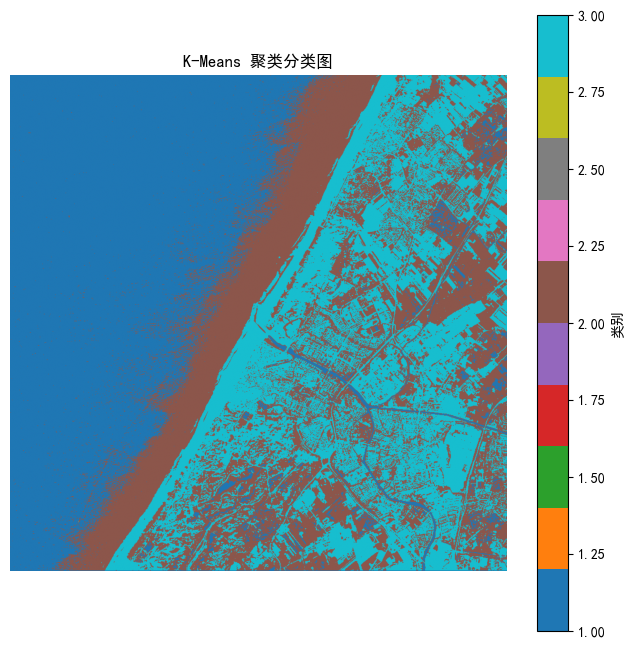

已保存： output/exp3_kmeans\KMeans聚类分类图.png


In [68]:
plt.figure(figsize=(8, 8))
plt.imshow(reclassified_map, cmap="tab10")
plt.title("K-Means 聚类分类图")
plt.colorbar(label="类别")
plt.axis("off")
save_path = os.path.join(output_dir, "KMeans聚类分类图.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()
print("已保存：", save_path)

In [69]:
class_list = []
pixel_count_list = []
area_list = []
ratio_list = []
meaning_list = []
for class_id in range(1, n_classes + 1):
    class_pixels = np.sum(reclassified_map == class_id)
    class_area = class_pixels * pixel_area
    class_ratio = class_pixels / total_pixels
    class_list.append(class_id)
    pixel_count_list.append(class_pixels)
    area_list.append(class_area)
    ratio_list.append(class_ratio)
    if class_id == 1:
        meaning_list.append("暗色区域，可能为水体、阴影或低反射地物")
    elif class_id == 2:
        meaning_list.append("中等亮度区域，可能为植被、农田或一般地表")
    elif class_id == 3:
        meaning_list.append("高亮区域，可能为建筑、道路、裸地或高反射地物")
    else:
        meaning_list.append("其他类别")
statistics_df = pd.DataFrame({
    "类别": class_list,
    "可能含义": meaning_list,
    "像元数量": pixel_count_list,
    "面积": area_list,
    "面积比例": ratio_list
})
statistics_df

,类别,可能含义,像元数量,面积,面积比例
0,1,暗色区域，可能为水体、阴影或低反射地物,391698,39169800.0,0.390916
1,2,中等亮度区域，可能为植被、农田或一般地表,321141,32114100.0,0.320500
2,3,高亮区域，可能为建筑、道路、裸地或高反射地物,289162,28916200.0,0.288585


In [70]:
excel_path = os.path.join(output_dir, "分类面积统计表.xlsx")
statistics_df.to_excel(excel_path, index=False)
print("统计表已保存：", excel_path)

统计表已保存： output/exp3_kmeans\分类面积统计表.xlsx


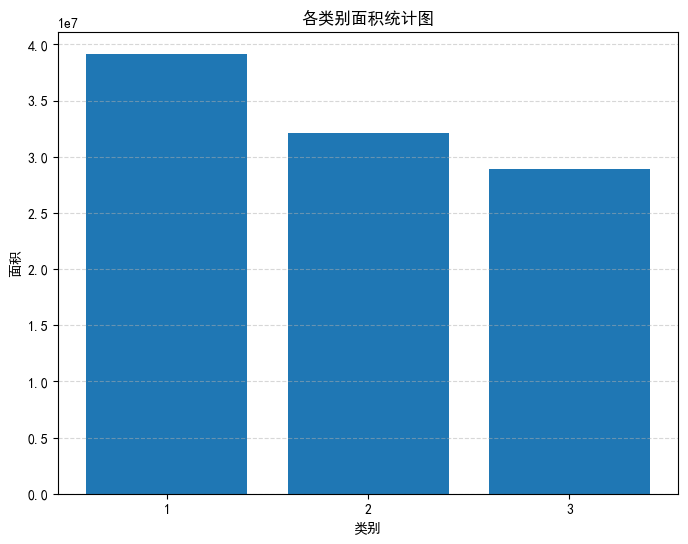

已保存： output/exp3_kmeans\分类面积统计图.png


In [71]:
plt.figure(figsize=(8, 6))
plt.bar(statistics_df["类别"].astype(str), statistics_df["面积"])
plt.title("各类别面积统计图")
plt.xlabel("类别")
plt.ylabel("面积")
plt.grid(axis="y", linestyle="--", alpha=0.5)
save_path = os.path.join(output_dir, "分类面积统计图.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()
print("已保存：", save_path)

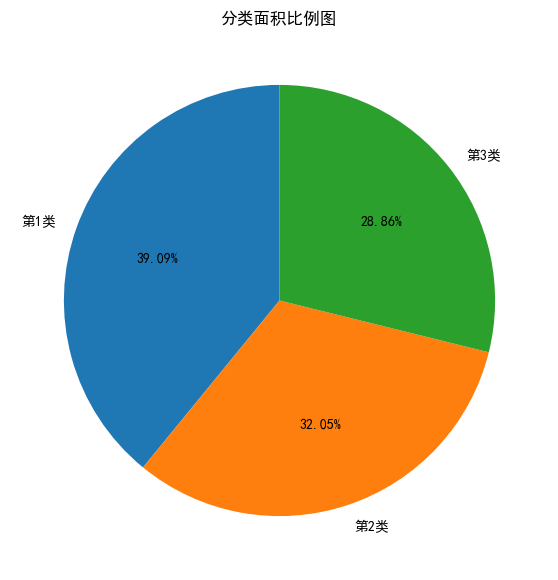

已保存： output/exp3_kmeans\分类面积比例图.png


In [72]:
plt.figure(figsize=(7, 7))
plt.pie(
    statistics_df["面积比例"],
    labels=["第1类", "第2类", "第3类"],
    autopct="%.2f%%",
    startangle=90
)
plt.title("分类面积比例图")
save_path = os.path.join(output_dir, "分类面积比例图.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()
print("已保存：", save_path)

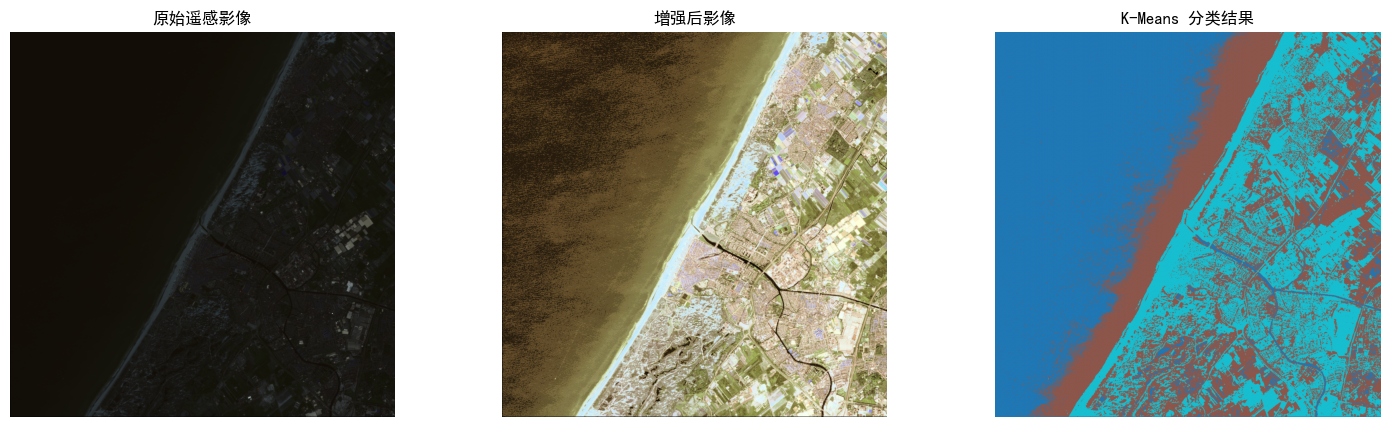

已保存： output/exp3_kmeans\综合对比图.png


In [73]:
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
plt.imshow(rgb_image)
plt.title("原始遥感影像")
plt.axis("off")
plt.subplot(1, 3, 2)
plt.imshow(enhanced_image)
plt.title("增强后影像")
plt.axis("off")
plt.subplot(1, 3, 3)
plt.imshow(reclassified_map, cmap="tab10")
plt.title("K-Means 分类结果")
plt.axis("off")
save_path = os.path.join(output_dir, "综合对比图.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()
print("已保存：", save_path)

<div style="font-size:17px; line-height:2; text-align:justify; text-indent:2em;">

本组实验以 Python 为主要工具，结合 Rasterio、OpenCV、NumPy、Scikit-learn、Matplotlib 和 Pandas 完成了 GIS 栅格数据处理与空间统计分析。实验一利用 Canny 算子对遥感影像进行边缘检测，并统计边缘像元数量和面积；实验二利用 Sobel 算子识别 DEM 或单波段栅格中的变化明显区域，并计算变化区面积比例；实验三利用 K-Means 方法对遥感影像进行简单聚类分类，并统计各类别面积和占比。
<br><br>

通过三个实验，可以掌握 GeoTIFF 数据读取、影像归一化、图像处理、像元统计、面积计算和结果制图的基本流程。实验结果表明，OpenCV 图像处理方法可以与 GIS 栅格数据结合，用于遥感影像边缘提取、地形变化识别和简单分类分析。但 Canny、Sobel 和 K-Means 方法受参数影响较大，结果仍需结合实际地物情况进行解释和验证。
</div>